Toronto Snowfall Trend Analysis
Station: Toronto long-term climate series (ClimID 6158350)
Dataset: ECCC Adjusted Daily Rainfall and Snowfall (AdjDlyRS)
Main analysis period: complete snow seasons from 1954–55 onward, subject to data completeness.
Goals
1. Load and parse the fixed-width daily file.
2. Handle missing-value codes correctly.
3. Convert archived snowfall to centimetres.
4. Build July–June snow seasons.
5. Check seasonal completeness.
6. Calculate seasonal snowfall totals.
7. Estimate the long-term linear snowfall trend.
8. Identify snowiest and least snowy seasons.
9. Save clean outputs and a presentation-ready figure.
Important: the raw snowfall archive uses -99999 for missing values.
snow_raw is the original snowfall measurement; archived daily total snowfall is stored in tenths of a centimetre, so snowfall_cm = snow_raw / 10.

In [1]:

from pathlib import Path
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


# 1. Locate the Toronto daily snowfall file

In [2]:

# Works whether the notebook is run from notebooks/ or the project root.
cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

candidates = list(PROJECT_ROOT.rglob("6158350_QCdRSP.txt"))

if not candidates:
    raise FileNotFoundError(
        "Could not find 6158350_QCdRSP.txt inside the project. "
        "Place the extracted AdjDlyRS data somewhere under the project folder."
    )

SNOW_PATH = candidates[0]

print("Project root:", PROJECT_ROOT)
print("Snowfall file:", SNOW_PATH)


Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis
Snowfall file: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/raw/snowfall/stns3346_dataQCed_20250215/DLY/6158350_QCdRSP.txt


# Parse the fixed-width ECCC file

In [3]:

# Fixed-width positions based on the AdjDlyRS daily text layout.
colspecs = [
    (0, 7), (8, 12), (12, 14), (14, 16),
    (18, 21), (23, 27),

    (28, 34), (34, 35),
    (36, 44), (44, 45),
    (46, 54), (54, 57),

    (58, 64), (64, 65),
    (66, 74), (74, 75),
    (76, 84), (84, 87),

    (88, 96), (96, 102),
    (103, 111), (111, 117)
]

columns = [
    "clim_id", "year", "month", "day",
    "source", "name",

    "rain_raw", "rain_raw_flag",
    "rain_c1_mm", "rain_c1_flag",
    "rain_corrected_mm", "rain_flags",

    "snow_raw", "snow_raw_flag",
    "snow_c1_mm", "snow_c1_flag",
    "snow_corrected_mm", "snow_flags",

    "precip_corrected_mm", "precip_flags",
    "precip_qc_mm", "precip_qc_flags"
]

snow_df = pd.read_fwf(
    SNOW_PATH,
    skiprows=1,
    colspecs=colspecs,
    names=columns
)

print("Shape:", snow_df.shape)
display(snow_df.head())
print(snow_df.dtypes)


Shape: (64648, 22)


,clim_id,year,month,day,source,name,rain_raw,rain_raw_flag,rain_c1_mm,rain_c1_flag,rain_corrected_mm,rain_flags,snow_raw,snow_raw_flag,snow_c1_mm,snow_c1_flag,snow_corrected_mm,snow_flags,precip_corrected_mm,precip_flags,precip_qc_mm,precip_qc_flags
0,6158350,1840,5,1,0n1,RSFT,64,NaN,6.874,R,6.874,R,0,NaN,0.0,NaN,0.0,NaN,6.874,R,6.874,R
1,6158350,1840,5,2,0n1,RSFT,0,NaN,0.000,NaN,0.000,NaN,0,NaN,0.0,NaN,0.0,NaN,0.000,NaN,0.000,NaN
2,6158350,1840,5,3,0n1,RSFT,99,NaN,10.514,R,10.514,R,0,NaN,0.0,NaN,0.0,NaN,10.514,R,10.514,R
3,6158350,1840,5,4,0n1,RSFT,127,NaN,13.426,R,13.426,R,0,NaN,0.0,NaN,0.0,NaN,13.426,R,13.426,R
4,6158350,1840,5,5,0n1,RSFT,0,NaN,0.000,NaN,0.000,NaN,0,NaN,0.0,NaN,0.0,NaN,0.000,NaN,0.000,NaN


clim_id                  int64
year                     int64
month                    int64
day                      int64
source                     str
name                       str
rain_raw                 int64
rain_raw_flag              str
rain_c1_mm             float64
rain_c1_flag               str
rain_corrected_mm      float64
rain_flags                 str
snow_raw                 int64
snow_raw_flag              str
snow_c1_mm             float64
snow_c1_flag               str
snow_corrected_mm      float64
snow_flags                 str
precip_corrected_mm    float64
precip_flags               str
precip_qc_mm           float64
precip_qc_flags            str
dtype: object


# Create dates and inspect data quality

In [4]:

snow_df["date"] = pd.to_datetime(
    snow_df[["year", "month", "day"]],
    errors="coerce"
)

print("Date range:", snow_df["date"].min(), "→", snow_df["date"].max())
print("Invalid dates:", snow_df["date"].isna().sum())
print("Duplicate dates:", snow_df["date"].duplicated().sum())
print("Station IDs:", snow_df["clim_id"].dropna().unique())


Date range: 1840-05-01 00:00:00 → 2017-04-30 00:00:00
Invalid dates: 0
Duplicate dates: 0
Station IDs: [6158350]


# Handle missing snowfall values correctly

In [5]:

# Inspect negative snowfall codes before replacing them.
negative_codes = (
    snow_df.loc[snow_df["snow_raw"] < 0, "snow_raw"]
    .value_counts()
    .sort_index()
)

print("Negative snowfall codes found:")
display(negative_codes)


Negative snowfall codes found:


snow_raw
-99999    3746
Name: count, dtype: int64

In [6]:

# ECCC archive missing code is -99999.
# We also treat any negative snowfall as invalid because physical snowfall depth cannot be negative.
snow_df["snow_raw_clean"] = snow_df["snow_raw"].astype(float)

snow_df.loc[
    snow_df["snow_raw_clean"] < 0,
    "snow_raw_clean"
] = np.nan

# Archived daily snowfall is in 0.1 cm.
snow_df["snowfall_cm"] = snow_df["snow_raw_clean"] / 10.0

print("Missing snowfall after cleaning:", snow_df["snowfall_cm"].isna().sum())
print("Minimum valid snowfall:", snow_df["snowfall_cm"].min(), "cm")
print("Maximum daily snowfall:", snow_df["snowfall_cm"].max(), "cm")


Missing snowfall after cleaning: 3746
Minimum valid snowfall: 0.0 cm
Maximum daily snowfall: 48.3 cm


# Inspect actual snowfall days

In [7]:

snow_days = snow_df.loc[
    snow_df["snowfall_cm"] > 0,
    ["date", "snowfall_cm", "snow_raw_flag"]
].copy()

display(snow_days.head(20))

print("Number of days with measurable snowfall:", len(snow_days))


,date,snowfall_cm,snow_raw_flag
2073,1846-01-03,1.0,NaN
2077,1846-01-07,7.6,NaN
2079,1846-01-09,1.0,NaN
2081,1846-01-11,0.5,NaN
2084,1846-01-14,0.5,NaN
2092,1846-01-22,2.0,NaN
2097,1846-01-27,2.5,NaN
2102,1846-02-01,0.5,NaN
2112,1846-02-11,10.2,NaN
2113,1846-02-12,12.7,NaN


Number of days with measurable snowfall: 7817


# 6. Define snow seasons
A snow season is labelled by the year in which it ends:
- 1954-07-01 to 1955-06-30 → season 1955
- 1955-07-01 to 1956-06-30 → season 1956
Using July–June keeps one winter together instead of splitting December from January–March.

In [8]:

# Align the beginning with the temperature-analysis era.
# Stop at 2016-06-30 so every requested season is a complete July–June window.
snow_analysis = snow_df[
    snow_df["date"].between("1954-07-01", "2016-06-30")
].copy()

snow_analysis["season_year"] = np.where(
    snow_analysis["month"] >= 7,
    snow_analysis["year"] + 1,
    snow_analysis["year"]
)

print(
    "Analysis date range:",
    snow_analysis["date"].min(),
    "→",
    snow_analysis["date"].max()
)

print(
    "Season range:",
    snow_analysis["season_year"].min(),
    "→",
    snow_analysis["season_year"].max()
)


Analysis date range: 1954-07-01 00:00:00 → 2016-06-30 00:00:00
Season range: 1955 → 2016


# 7. Seasonal completeness

In [9]:

seasonal_snow = (
    snow_analysis.groupby("season_year")
    .agg(
        snowfall_cm=("snowfall_cm", lambda x: x.sum(min_count=1)),
        valid_days=("snowfall_cm", "count"),
        observed_rows=("date", "count")
    )
    .reset_index()
)

def expected_days_for_season(season_year):
    start = pd.Timestamp(year=int(season_year) - 1, month=7, day=1)
    end = pd.Timestamp(year=int(season_year), month=6, day=30)
    return (end - start).days + 1

seasonal_snow["expected_days"] = seasonal_snow["season_year"].apply(
    expected_days_for_season
)

seasonal_snow["coverage_pct"] = (
    seasonal_snow["valid_days"]
    / seasonal_snow["expected_days"]
    * 100
)

# Same general rule used elsewhere in the climate project:
# require at least 90% valid daily values.
seasonal_snow["usable"] = seasonal_snow["coverage_pct"] >= 90

display(seasonal_snow.head())
display(seasonal_snow.tail())

print("\nCoverage summary:")
display(seasonal_snow["coverage_pct"].describe())

print("\nUnusable seasons:")
display(
    seasonal_snow.loc[
        ~seasonal_snow["usable"],
        ["season_year", "snowfall_cm", "valid_days", "expected_days", "coverage_pct"]
    ]
)


,season_year,snowfall_cm,valid_days,observed_rows,expected_days,coverage_pct,usable
0,1955,126.4,365,365,365,100.0,True
1,1956,174.2,366,366,366,100.0,True
2,1957,133.0,365,365,365,100.0,True
3,1958,80.2,365,365,365,100.0,True
4,1959,166.5,365,365,365,100.0,True


,season_year,snowfall_cm,valid_days,observed_rows,expected_days,coverage_pct,usable
57,2012,34.1,137,366,366,37.431694,False
58,2013,124.0,165,365,365,45.205479,False
59,2014,151.6,167,365,365,45.753425,False
60,2015,104.1,167,365,365,45.753425,False
61,2016,59.7,168,366,366,45.901639,False



Coverage summary:


count     62.000000
mean      89.236096
std       21.264370
min       37.431694
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: coverage_pct, dtype: float64


Unusable seasons:


,season_year,snowfall_cm,valid_days,expected_days,coverage_pct
49,2004,110.1,213,366,58.196721
50,2005,139.4,212,365,58.082192
51,2006,70.4,212,365,58.082192
52,2007,67.9,197,365,53.972603
53,2008,209.7,167,366,45.628415
54,2009,130.1,167,365,45.753425
55,2010,46.2,181,365,49.589041
56,2011,124.3,158,365,43.287671
57,2012,34.1,137,366,37.431694
58,2013,124.0,165,365,45.205479


# 8. Keep only usable seasons

In [10]:

seasonal_snow.loc[
    ~seasonal_snow["usable"],
    "snowfall_cm"
] = np.nan

trend_data = seasonal_snow.dropna(
    subset=["snowfall_cm"]
).copy()

print("Usable seasons:", len(trend_data))
print(
    "Usable season range:",
    trend_data["season_year"].min(),
    "→",
    trend_data["season_year"].max()
)

display(trend_data.head())
display(trend_data.tail())


Usable seasons: 49
Usable season range: 1955 → 2003


,season_year,snowfall_cm,valid_days,observed_rows,expected_days,coverage_pct,usable
0,1955,126.4,365,365,365,100.0,True
1,1956,174.2,366,366,366,100.0,True
2,1957,133.0,365,365,365,100.0,True
3,1958,80.2,365,365,365,100.0,True
4,1959,166.5,365,365,365,100.0,True


,season_year,snowfall_cm,valid_days,observed_rows,expected_days,coverage_pct,usable
44,1999,162.2,365,365,365,100.0,True
45,2000,82.8,366,366,366,100.0,True
46,2001,165.6,365,365,365,100.0,True
47,2002,71.4,365,365,365,100.0,True
48,2003,162.5,365,365,365,100.0,True


# 9. Long-term snowfall trend

In [11]:

if len(trend_data) < 2:
    raise ValueError("Not enough usable seasons to calculate a trend.")

snow_result = linregress(
    trend_data["season_year"],
    trend_data["snowfall_cm"]
)

snow_slope_decade = snow_result.slope * 10
snow_pvalue = snow_result.pvalue
snow_r2 = snow_result.rvalue ** 2
snow_avg = trend_data["snowfall_cm"].mean()

print(f"Snowfall trend: {snow_slope_decade:.2f} cm/decade")
print(f"p-value: {snow_pvalue:.4f}")
print(f"R²: {snow_r2:.3f}")
print(f"Average seasonal snowfall: {snow_avg:.1f} cm")


Snowfall trend: -4.43 cm/decade
p-value: 0.2117
R²: 0.033
Average seasonal snowfall: 134.6 cm


In [12]:

direction = "increasing" if snow_slope_decade > 0 else "decreasing"
significance = (
    "statistically significant at α = 0.05"
    if snow_pvalue < 0.05
    else "not statistically significant at α = 0.05"
)

print(
    f"Interpretation: Seasonal snowfall is estimated to be {direction} "
    f"at {abs(snow_slope_decade):.2f} cm per decade. "
    f"The linear trend is {significance} "
    f"(p = {snow_pvalue:.4f}, R² = {snow_r2:.3f})."
)


Interpretation: Seasonal snowfall is estimated to be decreasing at 4.43 cm per decade. The linear trend is not statistically significant at α = 0.05 (p = 0.2117, R² = 0.033).


# 10. Snowiest and least snowy seasons

In [13]:

print("Snowiest seasons:")
display(
    trend_data.nlargest(5, "snowfall_cm")[
        ["season_year", "snowfall_cm", "coverage_pct"]
    ]
)

print("Least snowy seasons:")
display(
    trend_data.nsmallest(5, "snowfall_cm")[
        ["season_year", "snowfall_cm", "coverage_pct"]
    ]
)


Snowiest seasons:


,season_year,snowfall_cm,coverage_pct
5,1960,211.3,100.0
16,1971,188.3,100.0
10,1965,182.1,100.0
17,1972,180.1,100.0
23,1978,177.3,100.0


Least snowy seasons:


,season_year,snowfall_cm,coverage_pct
47,2002,71.4,100.0
28,1983,73.0,100.0
40,1995,75.4,100.0
3,1958,80.2,100.0
45,2000,82.8,100.0


# 11. Compare early and recent periods

In [14]:

# Compare the first and last 10 usable seasons, if enough data exist.
if len(trend_data) >= 20:
    first_10 = trend_data.nsmallest(10, "season_year")
    last_10 = trend_data.nlargest(10, "season_year")

    first_10_avg = first_10["snowfall_cm"].mean()
    last_10_avg = last_10["snowfall_cm"].mean()
    difference = last_10_avg - first_10_avg

    print(f"First 10 usable seasons average: {first_10_avg:.1f} cm")
    print(f"Last 10 usable seasons average: {last_10_avg:.1f} cm")
    print(f"Difference: {difference:+.1f} cm")
else:
    print("Not enough usable seasons for a 10-season early/recent comparison.")


First 10 usable seasons average: 138.1 cm
Last 10 usable seasons average: 130.5 cm
Difference: -7.6 cm


# 12. Plot seasonal snowfall with linear trend

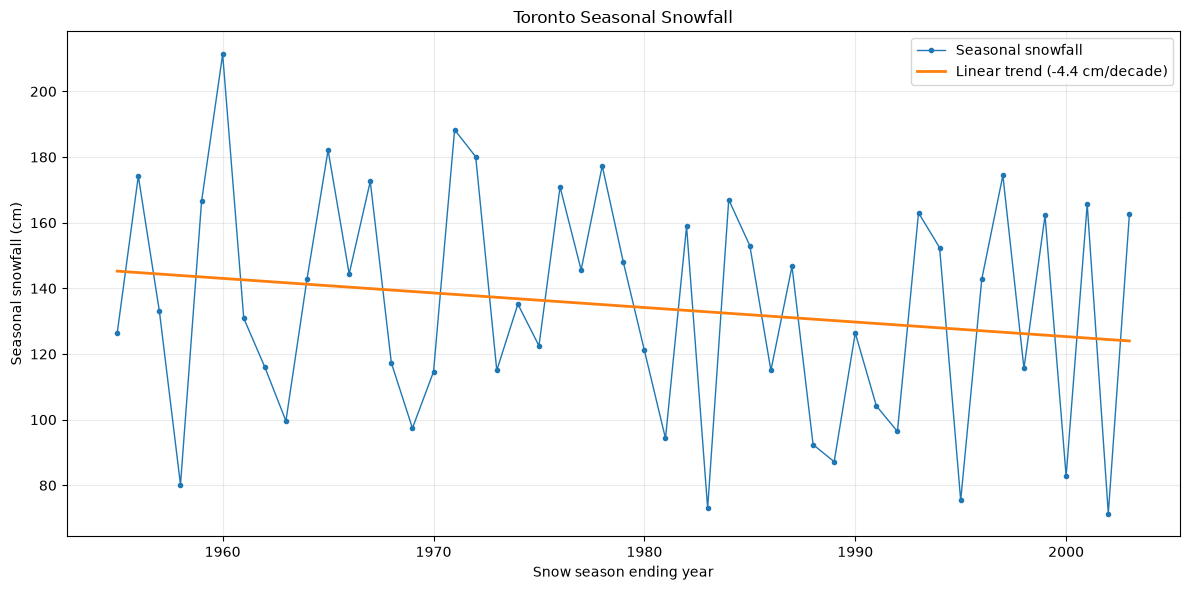

In [15]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    trend_data["season_year"],
    trend_data["snowfall_cm"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Seasonal snowfall"
)

trend_line = (
    snow_result.intercept
    + snow_result.slope * trend_data["season_year"]
)

ax.plot(
    trend_data["season_year"],
    trend_line,
    linewidth=2,
    label=f"Linear trend ({snow_slope_decade:+.1f} cm/decade)"
)

ax.set_title("Toronto Seasonal Snowfall")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

plt.show()


# 13. Optional 10-season rolling mean

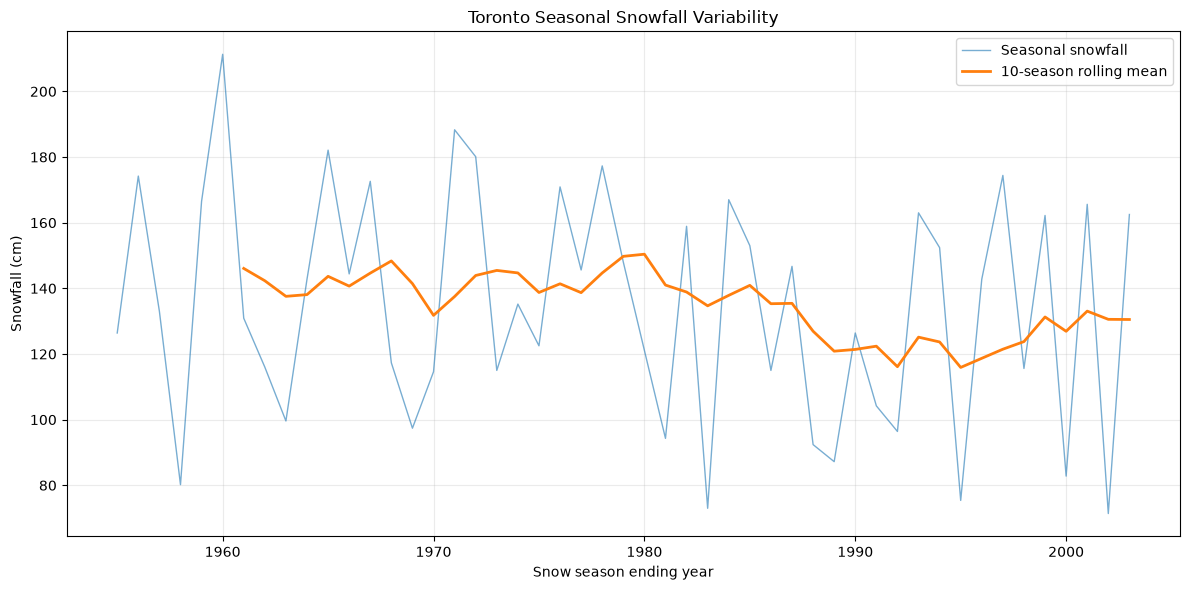

In [16]:

trend_data = trend_data.sort_values("season_year").copy()

trend_data["rolling_10yr"] = (
    trend_data["snowfall_cm"]
    .rolling(window=10, min_periods=7)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    trend_data["season_year"],
    trend_data["snowfall_cm"],
    linewidth=1,
    alpha=0.6,
    label="Seasonal snowfall"
)

ax.plot(
    trend_data["season_year"],
    trend_data["rolling_10yr"],
    linewidth=2,
    label="10-season rolling mean"
)

ax.set_title("Toronto Seasonal Snowfall Variability")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

plt.show()


# 14. Save processed data and figure

In [17]:

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

seasonal_output = seasonal_snow[
    [
        "season_year",
        "snowfall_cm",
        "valid_days",
        "expected_days",
        "coverage_pct",
        "usable"
    ]
].copy()

seasonal_output.to_csv(
    PROCESSED_DIR / "toronto_seasonal_snowfall.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    trend_data["season_year"],
    trend_data["snowfall_cm"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Seasonal snowfall"
)

ax.plot(
    trend_data["season_year"],
    snow_result.intercept + snow_result.slope * trend_data["season_year"],
    linewidth=2,
    label=f"Linear trend ({snow_slope_decade:+.1f} cm/decade)"
)

ax.set_title("Toronto Seasonal Snowfall")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "toronto_seasonal_snowfall_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Saved:")
print(PROCESSED_DIR / "toronto_seasonal_snowfall.csv")
print(FIGURES_DIR / "toronto_seasonal_snowfall_trend.png")


Saved:
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/toronto_seasonal_snowfall.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/figures/toronto_seasonal_snowfall_trend.png


15. Final interpretation template
After running the notebook, report the result in this form:
From the usable Toronto snow seasons in the analysis period, seasonal snowfall showed an estimated trend of X cm per decade. The trend was [statistically significant / not statistically significant] at the 5% level (p = X, R² = X). Average seasonal snowfall was approximately X cm.

Limitations
- The daily AdjDlyRS record for this Toronto series ends before the temperature series.
- Missing daily snowfall values are excluded rather than treated as zero.
- Seasons below 90% valid daily coverage are excluded from the trend.
- The AdjDlyRS product contains measurement adjustments and quality-control processing; it is not identical to the AHCCD temperature product.
- A linear trend summarizes the long-run direction but does not capture every decadal fluctuation.